In [14]:
from auditoryforage.utils import open_pickle_file
folder_name = './store/comparison/'
file_name = folder_name + 'diff_food_rewards.pkl'
detection_measures = open_pickle_file(file_name)

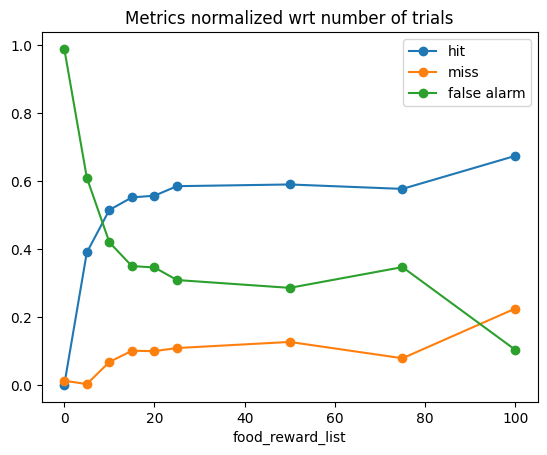

In [15]:
import numpy as np
import matplotlib.pyplot as plt
food_reward_list = detection_measures['input']['food_reward_list']
max_food_ind = len(food_reward_list)
# max_food_ind = 9

# Plotting any one seed
# max_ind_list = [2 for rate_list in detection_measures['output']['hit_count_list']]

# Plotting best case scenario
max_ind_list = [count.index(max(count)) for count in detection_measures['output']['hit_count_list']]

max_hit_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['hit_count_list'])]
max_miss_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['miss_count_list'])]
max_false_alarm_count_normalized = [count[max_ind_list[ind]]/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['false_alarm_list'])]
plt.plot(food_reward_list[:max_food_ind], max_hit_count_normalized[:max_food_ind], 'o-')
plt.plot(food_reward_list[:max_food_ind], max_miss_count_normalized[:max_food_ind], 'o-')
plt.plot(food_reward_list[:max_food_ind], max_false_alarm_count_normalized[:max_food_ind], 'o-')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('food_reward_list')
plt.title('Metrics normalized wrt number of trials')
plt.show()

In [16]:
print(food_reward_list[:max_food_ind])
print(max_hit_count_normalized[:max_food_ind])
print(max_miss_count_normalized[:max_food_ind])
print(max_false_alarm_count_normalized[:max_food_ind])

[0, 5.0, 10.0, 15.0, 20.0, 25.0, 50.0, 75.0, 100.0]
[0.0, 0.389, 0.514, 0.551, 0.556, 0.584, 0.589, 0.576, 0.673]
[0.012, 0.002, 0.067, 0.1, 0.099, 0.108, 0.126, 0.078, 0.224]
[0.988, 0.609, 0.419, 0.349, 0.345, 0.308, 0.285, 0.346, 0.103]


In [17]:
print(max_ind_list)

[0, 2, 0, 3, 2, 3, 4, 1, 4]


/var/folders/fk/llp481rj57s9xl97ppf74zcw0000gn/T/ipykernel_87206/1098569361.py:17: RuntimeWarning: invalid value encountered in divide
  max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]


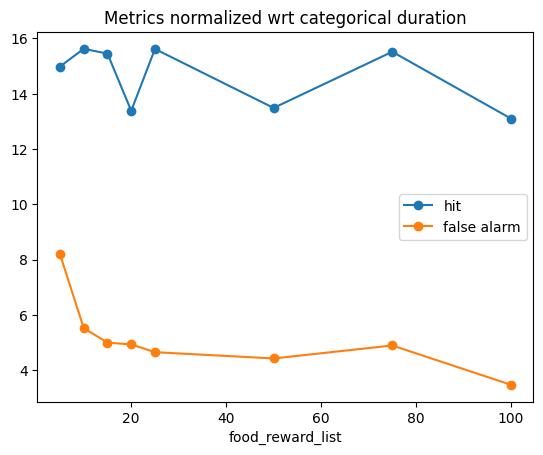

In [18]:
import numpy as np
import matplotlib.pyplot as plt
food_reward_list = detection_measures['input']['food_reward_list']
min_food_ind = 1

max_food_ind = len(food_reward_list)
# max_food_ind = 9
one_step_in_seconds = .001

# Plotting any one seed
# max_ind_list = [2 for rate_list in detection_measures['output']['hit_count_list']]

# Plotting best case scenario
max_ind_list = [rate_list.index(max(rate_list)) for rate_list in detection_measures['output']['hit_count_list']]

temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['hit_count_list'], detection_measures['output']['signal_time_before_lick_list'])
max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]
temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['false_alarm_list'], detection_measures['output']['noise_time_before_lick_list'])
max_false_alarm_rate = [np.array(count[max_ind_list[ind]])/(duration[max_ind_list[ind]] * one_step_in_seconds) for ind, count, duration in temp_zip]
plt.plot(food_reward_list[min_food_ind:max_food_ind], max_hit_rate[min_food_ind:max_food_ind], 'o-')
plt.plot(food_reward_list[min_food_ind:max_food_ind], max_false_alarm_rate[min_food_ind:max_food_ind], 'o-')
plt.legend(['hit', 'false alarm'])
plt.xlabel('food_reward_list')
plt.title('Metrics normalized wrt categorical duration')
plt.show()

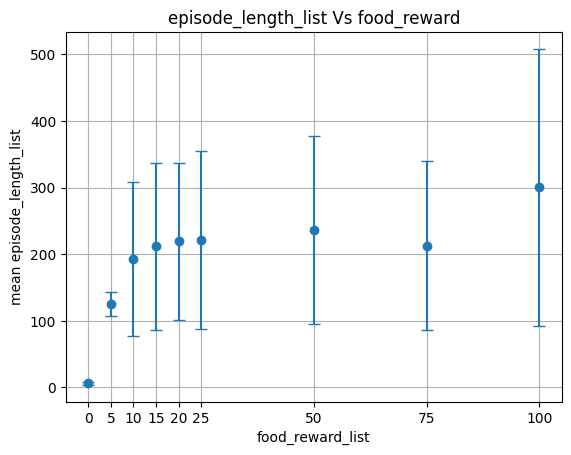

In [19]:
attention_time_points_list = detection_measures['output']['attention_time_points_list']
episode_length_list = detection_measures['output']['episode_length_list']

episode_length_mean_list = []
episode_length_std_list = []

# for exp_ind in range(episode_length_list):
#     episode_length_mean_list.append(np.mean(episode_length) for episode_length in episode_length_list)
#     episode_length_std_list.append(np.std(episode_length) for episode_length in episode_length_list)
# episode_length_mean_list_chosen = [episode_length_mean_list[ind][max_ind_list[ind]] for ind in range(max_ind_list)]
# episode_length_std_list_chosen = [episode_length_std_list[ind][max_ind_list[ind]] for ind in range(max_ind_list)]
# plt.figure()
# plt.errorbar(food_reward_list, episode_length_mean_list_chosen, yerr= episode_length_std_list_chosen, fmt='o', markersize=6, capsize=4)
# plt.xlabel('food_reward_list')
# plt.ylabel('mean episode_length_list')
# plt.title('episode_length_list Vs food_reward_list')
# plt.xticks(np.arange(len(food_reward_list)))  # Set x-axis labels to column indices
# plt.grid()
# plt.show()



variable_list = [episode_length_list]
variable = episode_length_list
mean_list = []
std_list = []
for exp_ind in range(len(episode_length_list)):
    mean_list.append([np.mean(elt) for elt in variable[exp_ind]])
    std_list.append([np.std(elt) for elt in variable[exp_ind]])
variable_mean_list_chosen = [mean_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
variable_std_list_chosen = [std_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
plt.figure()
plt.errorbar(food_reward_list, variable_mean_list_chosen, yerr= variable_std_list_chosen, fmt='o', markersize=6, capsize=4)
plt.xlabel('food_reward_list')
variable_name = [name for name, value in globals().items() if value is variable][0]
plt.ylabel(f'mean {variable_name}')
plt.title(f'{variable_name} Vs food_reward')
plt.xticks(food_reward_list)  # Set x-axis labels to column indices
plt.grid()
plt.show()

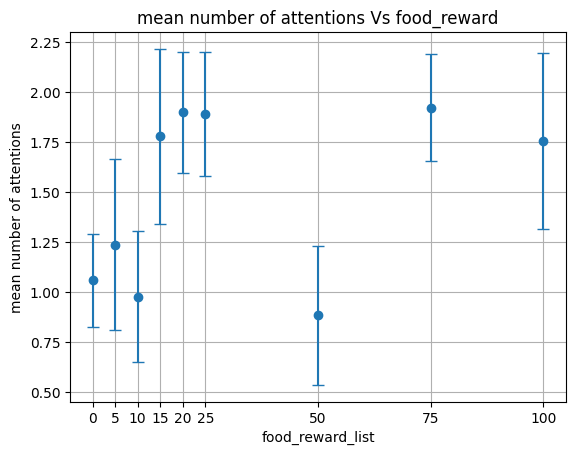

In [20]:
# len(attention_time_points_list)
# print([len(attention_time_points_list[exp_ind][max_ind_list[ind]]) for ind in range(len(max_ind_list))] for exp_ind in range(len(attention_time_points_list))])

# [len(attention_time_points_list[ind][max_ind_list[ind]]) for ind in range(len(max_ind_list))]

# chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]

variable_mean_list_chosen = []
variable_std_list_chosen = []
for ind in range(len(chosen_attention_time_points_list)):

    # Correct
    # variable_mean_list_chosen.append(np.mean([len(episode) for episode in chosen_attention_time_points_list[ind]]))
    # variable_std_list_chosen.append(np.std([len(episode) for episode in chosen_attention_time_points_list[ind]]))

    # Temporary adjustment
    variable_mean_list_chosen.append(np.mean([len(episode[0]) for episode in chosen_attention_time_points_list[ind]]))
    variable_std_list_chosen.append(np.std([len(episode[0]) for episode in chosen_attention_time_points_list[ind]]))
plt.figure()
plt.errorbar(food_reward_list, variable_mean_list_chosen, yerr= variable_std_list_chosen, fmt='o', markersize=6, capsize=4)
plt.xlabel('food_reward_list')
plt.ylabel(f'mean number of attentions')
plt.title(f'mean number of attentions Vs food_reward')
plt.xticks(food_reward_list)  # Set x-axis labels to column indices
plt.grid()
plt.show()

In [21]:
# len(attention_time_points_list)
# print([len(attention_time_points_list[exp_ind][max_ind_list[ind]]) for ind in range(len(max_ind_list))] for exp_ind in range(len(attention_time_points_list))])

# [len(attention_time_points_list[ind][max_ind_list[ind]]) for ind in range(len(max_ind_list))]

# chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]

variable_mean_list_chosen = []
variable_std_list_chosen = []
for ind in range(len(chosen_attention_time_points_list)):

    # Correct, BUT CHECK if attention was made in first place!!!!
    variable_mean_list_chosen.append(np.mean([episode[-1] for episode in chosen_attention_time_points_list[ind]]))
    variable_std_list_chosen.append(np.std([episode[-1] for episode in chosen_attention_time_points_list[ind]]))

    # Temporary adjustment ALSO, ONLY cases where attention was made
    # variable_mean_list_chosen.append(np.mean([episode[0][-1] for episode in chosen_attention_time_points_list[ind] if len(episode[0]) != 0]))
    # variable_std_list_chosen.append(np.std([episode[0][-1] for episode in chosen_attention_time_points_list[ind] if len(episode[0]) != 0]))
plt.figure()
plt.errorbar(food_reward_list, variable_mean_list_chosen, yerr= variable_std_list_chosen, fmt='o', markersize=6, capsize=4)
plt.xlabel('food_reward_list')
plt.ylabel(f'mean last attention time point')
plt.title(f'mean last attention time point Vs food_reward')
plt.xticks(food_reward_list)  # Set x-axis labels to column indices
plt.grid()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1000,) + inhomogeneous part.

In [22]:
print(chosen_attention_time_points_list[0])
print(np.mean([episode[0][-1] for episode in chosen_attention_time_points_list[0] if len(episode[0]) != 0]))
print(np.sum([1 for episode in chosen_attention_time_points_list[0] if episode[0] == []]))

[(array([6]),), (array([4]),), (array([0, 4]),), (array([1]),), (array([7]),), (array([4]),), (array([1]),), (array([5]),), (array([4]),), (array([4]),), (array([3]),), (array([2]),), (array([4]),), (array([6]),), (array([2]),), (array([9]),), (array([2]),), (array([1]),), (array([7]),), (array([4]),), (array([1]),), (array([1]),), (array([3]),), (array([4]),), (array([5]),), (array([8]),), (array([10]),), (array([2]),), (array([3]),), (array([7]),), (array([3]),), (array([1]),), (array([1]),), (array([9]),), (array([1]),), (array([1]),), (array([3]),), (array([4]),), (array([9]),), (array([4]),), (array([5]),), (array([1]),), (array([4]),), (array([1]),), (array([7]),), (array([3]),), (array([7]),), (array([3]),), (array([4]),), (array([0, 2]),), (array([0, 2]),), (array([3]),), (array([8]),), (array([3]),), (array([0, 2]),), (array([0, 6]),), (array([3]),), (array([4]),), (array([2]),), (array([3]),), (array([3]),), (array([4]),), (array([0, 2]),), (array([5]),), (array([5]),), (arra

/var/folders/fk/llp481rj57s9xl97ppf74zcw0000gn/T/ipykernel_87206/2424519746.py:3: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  print(np.sum([1 for episode in chosen_attention_time_points_list[0] if episode[0] == []]))
/var/folders/fk/llp481rj57s9xl97ppf74zcw0000gn/T/ipykernel_87206/2424519746.py:3: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  print(np.sum([1 for episode in chosen_attention_time_points_list[0] if episode[0] == []]))


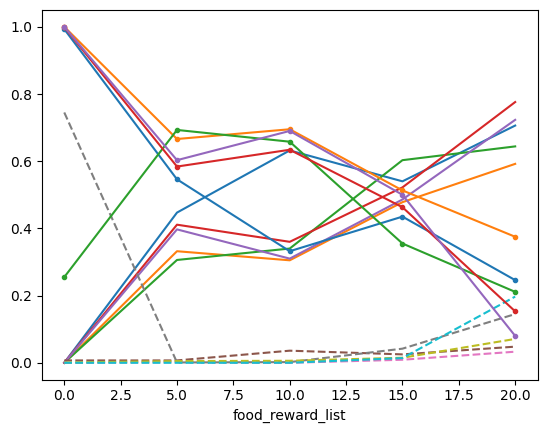

In [47]:
# Plotting all scenarios
import matplotlib.pyplot as plt
food_reward_list = detection_measures['input']['food_reward_list']

# max_food_ind = len(food_reward_list)
max_food_ind = 5

hit_count_list = detection_measures['output']['hit_count_list']
miss_count_list = detection_measures['output']['miss_count_list']
false_alarm_list = detection_measures['output']['false_alarm_list']
plt.plot(food_reward_list[:max_food_ind], hit_count_list[:max_food_ind], '-')
plt.plot(food_reward_list[:max_food_ind], miss_count_list[:max_food_ind], '--')
plt.plot(food_reward_list[:max_food_ind], false_alarm_list[:max_food_ind], '.-')
plt.xlabel('food_reward_list')
plt.show()

In [6]:
# import matplotlib.pyplot as plt
# seed_list = detection_measures['input']['seed_list']
# food_reward_list = detection_measures['input']['food_reward_list']
# hit_count_list = detection_measures['output']['hit_count_list']
# miss_count_list = detection_measures['output']['miss_count_list']
# false_alarm_list = detection_measures['output']['false_alarm_list']
# plt.plot(seed_list, hit_count_list, 'o-')
# plt.plot(seed_list, miss_count_list, '-*')
# plt.plot(seed_list, false_alarm_list, '-+')
# plt.legend(['hit', 'miss', 'false alarm'])
# plt.xlabel('seed_list')
# plt.show()

In [46]:
# # Adding new data to pickle file

# from auditoryforage.utils import open_pickle_file

# folder_name = './store/comparison/'
# name_1 = 'diff_food_rewards'
# name_2 = 'full_diff_food_rewards'

# file_name_1 = folder_name + name_1 +'.pkl'
# detection_measures_1 = open_pickle_file(file_name_1)
# food_reward_list_1 = detection_measures_1['input']['food_reward_list']

# file_name_2 = folder_name + name_2 +'.pkl'
# detection_measures_2 = open_pickle_file(file_name_2)
# food_reward_list_2 = detection_measures_2['input']['food_reward_list']

# full_food_reward_list = food_reward_list_1 + food_reward_list_2
# sorted_food_reward_list = sorted(full_food_reward_list)

# detection_measures = {}
# detection_measures['input'] = {}
# detection_measures['output'] = {}
# detection_measures['input']['food_reward_list'] = sorted_food_reward_list
# detection_measures['output'] = {}
# detection_measures['output']['hit_count_list'] = []
# detection_measures['output']['miss_count_list'] = []
# detection_measures['output']['false_alarm_list'] = []

# for food_reward in sorted_food_reward_list:
#     if food_reward in food_reward_list_1:
#         index = food_reward_list_1.index(food_reward)
#         detection_measures['output']['hit_count_list'].append(detection_measures_1['output']['hit_count_list'][index])
#         detection_measures['output']['miss_count_list'].append(detection_measures_1['output']['miss_count_list'][index])
#         detection_measures['output']['false_alarm_list'].append(detection_measures_1['output']['false_alarm_list'][index])
#     elif food_reward in food_reward_list_2:
#         index = food_reward_list_2.index(food_reward)
#         detection_measures['output']['hit_count_list'].append(detection_measures_2['output']['hit_count_list'][index])
#         detection_measures['output']['miss_count_list'].append(detection_measures_2['output']['miss_count_list'][index])
#         detection_measures['output']['false_alarm_list'].append(detection_measures_2['output']['false_alarm_list'][index])
#     else:
#         print("Something wrong")

# from auditoryforage.utils import save_pickle_file
# file_name = folder_name + 'combined_diff_food_rewards.pkl'
# save_pickle_file(detection_measures, file_name)